# Freight Rate Prediction — Analysis & Modeling

The objective is to predict `posted_rate` for unseen freight loads. The notebook is used as a single working space for data exploration, validation design, feature engineering, model experiments, and final model selection.

At this stage, the analysis focuses on understanding the structure of the development data, identifying data-quality issues, and defining a validation setup that reflects the future prediction period.


In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# sns.set_theme(style='whitegrid')


## Load the development data

The development dataset contains labeled historical loads. Dates are converted to `datetime` immediately because the temporal order of observations is important both for analysis and for validation.


In [2]:
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    DATA_DIR / 'train_test.csv',
    DATA_DIR / 'train-test.csv',
]

train_test_path = next((p for p in candidate_paths if p.exists()), None)
if train_test_path is None:
    raise FileNotFoundError('Could not find train_test.csv or train-test.csv in ../data/')

df = pd.read_csv(train_test_path)
df['date'] = pd.to_datetime(df['date'])

print(f'Loaded: {train_test_path}')
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')


Loaded: ../data/train-test.csv
Shape: (48000, 14)
Date range: 2025-01-01 -> 2025-10-31


## Data overview

The dataset contains **48,000 loads and 14 columns**. `posted_rate` is the continuous target variable, while the remaining columns describe route, shipment, equipment, market conditions, and time.

`load_id` uniquely identifies a load and does not describe its economic or operational characteristics, so it is treated as an identifier rather than a predictive feature.


In [3]:
print(df.info())
display(df.head())

print('\nColumn types:')
display(df.dtypes.to_frame('dtype'))

print(f'\nDuplicate rows: {df.duplicated().sum():,}')
print(f'Unique load_id values: {df["load_id"].nunique():,} / {len(df):,}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       48000 non-null  object        
 1   pickup        48000 non-null  object        
 2   delivery      48000 non-null  object        
 3   pickup_lat    48000 non-null  float64       
 4   pickup_lon    48000 non-null  float64       
 5   delivery_lat  48000 non-null  float64       
 6   delivery_lon  48000 non-null  float64       
 7   distance      48000 non-null  float64       
 8   equipment     48000 non-null  object        
 9   weight        47700 non-null  float64       
 10  date          48000 non-null  datetime64[ns]
 11  market_index  47626 non-null  float64       
 12  quote_signal  48000 non-null  float64       
 13  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(4)
memory usage: 5.1+ MB
None


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.091,-76.789,38.169,-72.746,274.300,Dry Van,"30,658.000",2025-01-01,0.957,2.396,645.410
1,TR-000002,Richmond,Philadelphia,38.091,-76.789,39.223,-72.967,280.500,Reefer,"17,555.000",2025-01-01,0.976,2.434,679.970
2,TR-000003,Philadelphia,Green Bay,39.223,-72.967,44.303,-87.529,967.800,Dry Van,"31,721.000",2025-01-01,1.010,1.845,"1,802.540"
3,TR-000004,Hartford,Atlanta,39.553,-72.181,34.849,-86.289,965.400,Dry Van,"32,333.000",2025-01-01,0.945,1.877,"1,827.280"
4,TR-000005,Dallas,Nashville,31.830,-94.383,35.295,-88.089,541.900,Reefer,"35,183.000",2025-01-01,0.985,2.563,"1,380.280"



Column types:


,dtype
load_id,object
pickup,object
delivery,object
pickup_lat,float64
pickup_lon,float64
delivery_lat,float64
delivery_lon,float64
distance,float64
equipment,object
weight,float64



Duplicate rows: 0
Unique load_id values: 48,000 / 48,000


## Missing values and data quality

Missing values are limited to `weight` and `market_index`, while the other fields are complete. The amount of missing data is small compared with the size of the dataset, so retaining these observations is preferable to dropping them.



In [25]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
})
display(missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False))



,missing_count,missing_pct
market_index,374,0.779
weight,300,0.625


##  Target analysis — `posted_rate`

`posted_rate` is strongly right-skewed: the mean is higher than the median and a relatively small number of loads have very high rates. The long upper tail is also clearly visible in the histogram and boxplot.

Most observations are concentrated in a substantially lower range than the maximum value, which means that large rates may have a disproportionate influence on squared-error based models. This makes the target distribution an important factor when comparing model objectives and possible target transformations later.


,posted_rate
count,"48,000.000"
mean,"2,373.981"
median,"2,030.760"
std,"1,486.493"
min,57.220
max,"25,533.000"
skew,1.902


,posted_rate
0.010,327.169
0.050,599.739
0.250,"1,251.555"
0.500,"2,030.760"
0.750,"3,330.750"
0.950,"4,953.766"
0.990,"5,972.834"


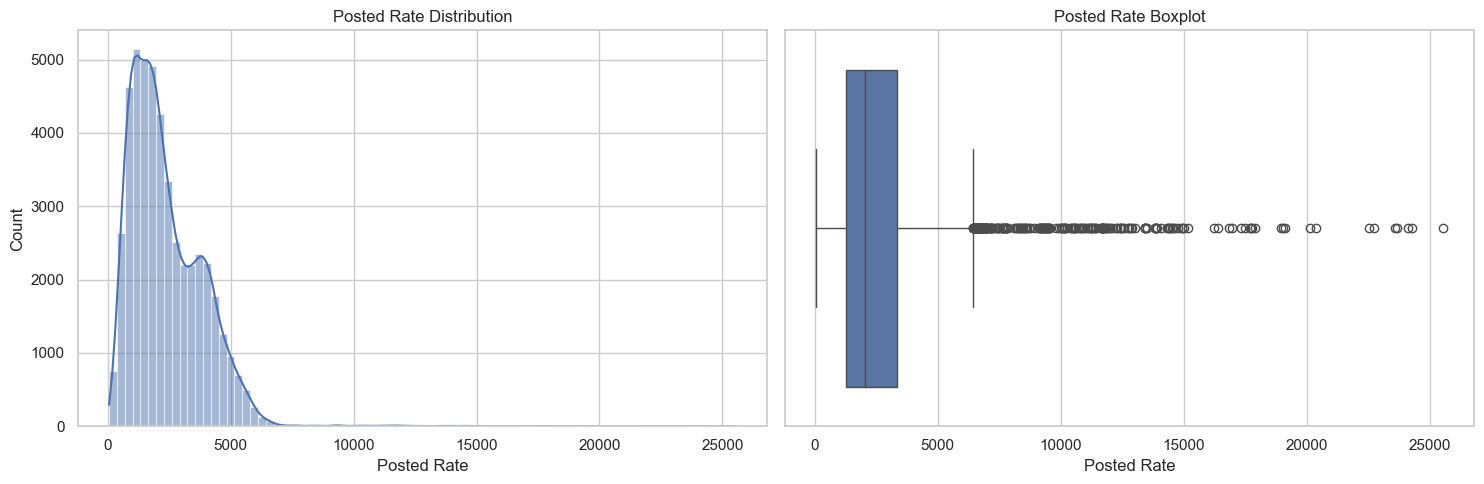

In [9]:
target_stats = df['posted_rate'].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew']).to_frame('posted_rate')
display(target_stats)

quantiles = df['posted_rate'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(quantiles.to_frame('posted_rate'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['posted_rate'], bins=80, kde=True, ax=axes[0])
axes[0].set_title('Posted Rate Distribution')
axes[0].set_xlabel('Posted Rate')

sns.boxplot(x=df['posted_rate'], ax=axes[1])
axes[1].set_title('Posted Rate Boxplot')
axes[1].set_xlabel('Posted Rate')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Numerical feature relationships

`distance` has by far the strongest linear relationship with `posted_rate` (correlation is approximately **0.91**), which makes it the dominant individual numerical signal in the dataset.

Other numerical variables show much weaker Pearson correlations with the target. This does not make them irrelevant: correlation captures only linear relationships, while market variables, weight, coordinates, and their interactions may still contribute to nonlinear models.


,correlation_with_posted_rate
posted_rate,1.000
distance,0.909
weight,0.035
market_index,0.034
quote_signal,-0.040
pickup_lat,-0.091
delivery_lat,-0.092
pickup_lon,-0.255
delivery_lon,-0.257


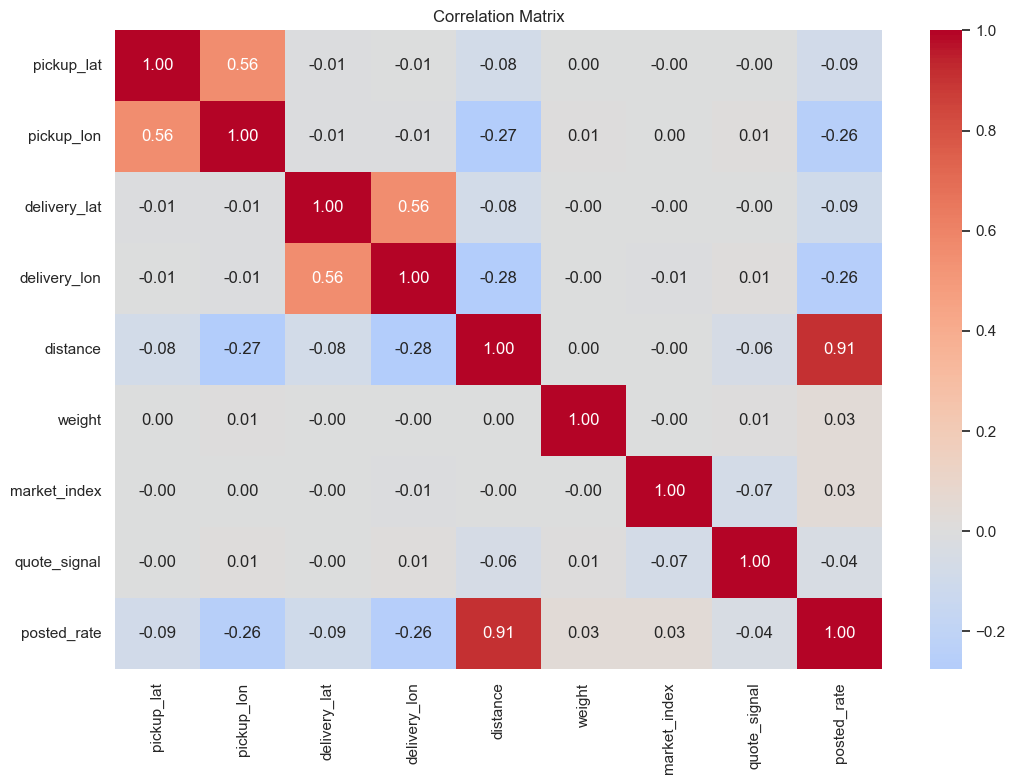

In [10]:
numeric_cols = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
                'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

corr = df[numeric_cols].corr()
display(corr['posted_rate'].sort_values(ascending=False).to_frame('correlation_with_posted_rate'))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


### Pairwise numerical relationships

A pairplot provides a broader view of the numerical feature space than the correlation matrix alone. A sample is used only for visualization so that the plot remains readable; it does not change the dataset used for modeling.

The main pattern remains the strong relationship between `distance` and `posted_rate`, while most other variables show much weaker direct structure. Coloring by `equipment` also helps reveal whether different equipment classes occupy slightly different regions of the feature space.


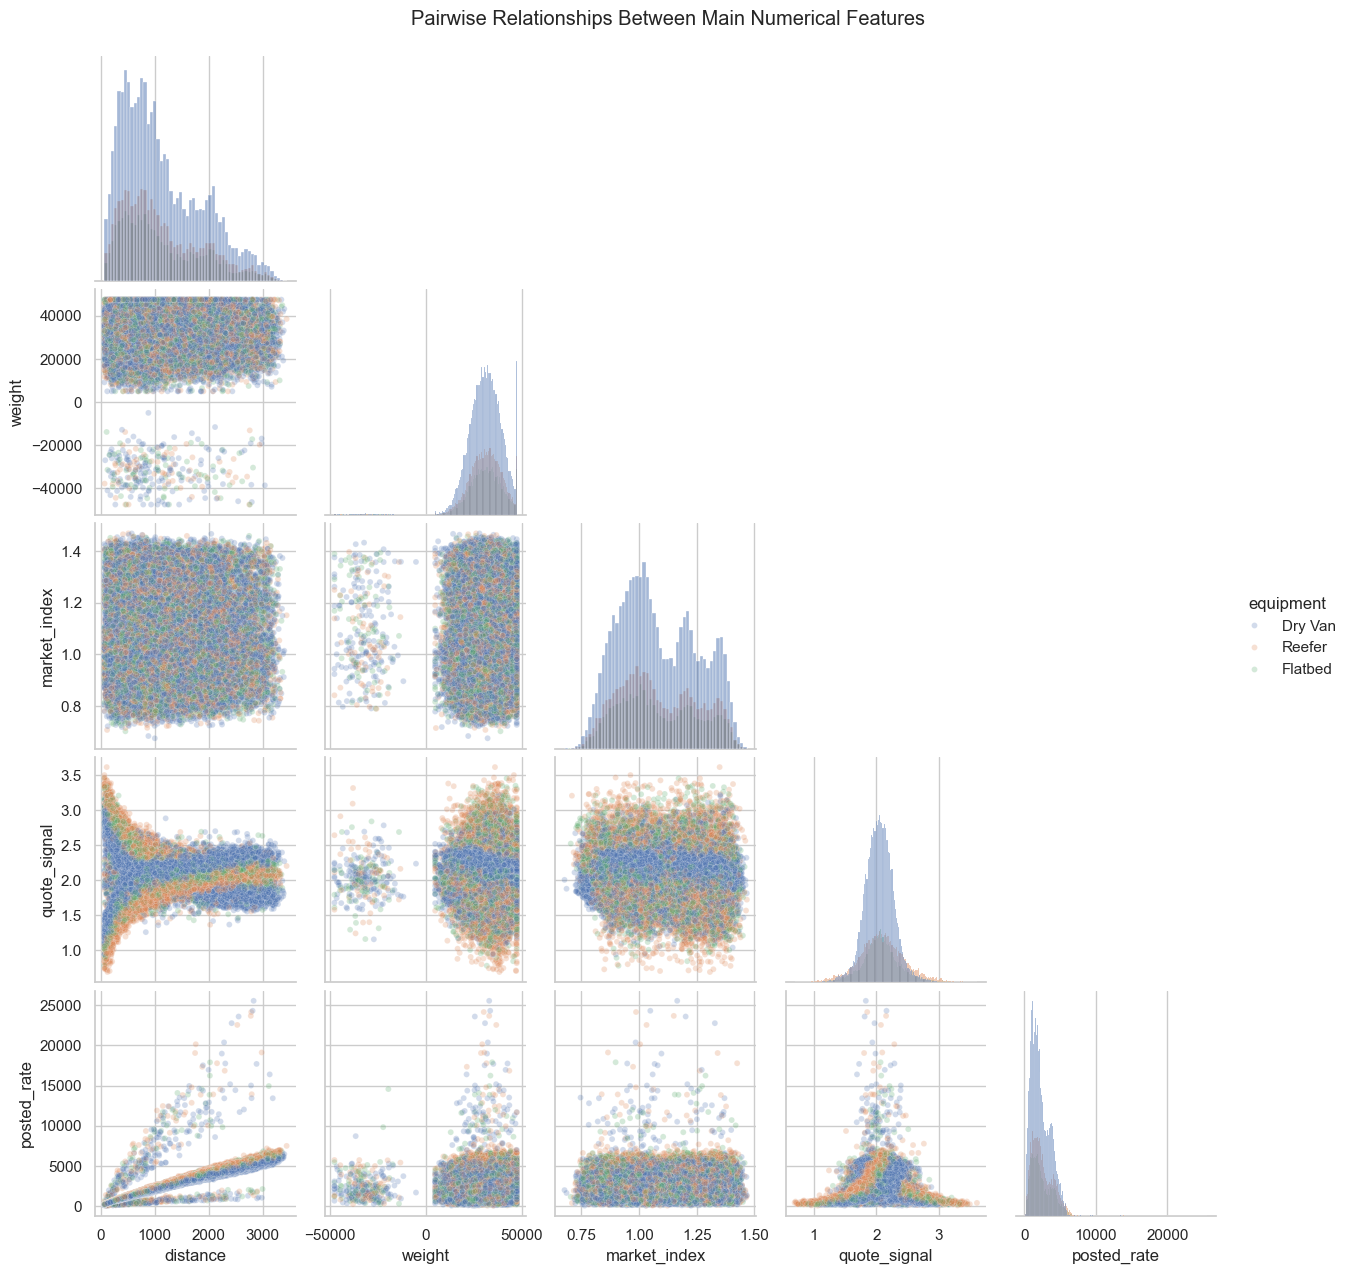

In [13]:
pairplot_cols = [
    'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'equipment'
]

pairplot_df = df[pairplot_cols].dropna().copy()

pair_grid = sns.pairplot(
    pairplot_df,
    vars=['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate'],
    hue='equipment',
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.25, 's': 18}
)
pair_grid.fig.suptitle('Pairwise Relationships Between Main Numerical Features', y=1.02)
pair_grid.savefig(OUTPUT_DIR / '03_pairplot.png', dpi=250, bbox_inches='tight')
plt.show()


## Distance vs. posted rate

The dedicated scatter plot confirms that freight rate grows strongly with distance. At the same time, the observations do not fall on a single narrow line: the vertical spread increases across the distance range and differs between loads.

This suggests that distance explains a large part of the base transportation cost, but additional shipment and market characteristics are needed to explain the remaining variation. The colored equipment groups also indicate that equipment type contributes to the rate structure.


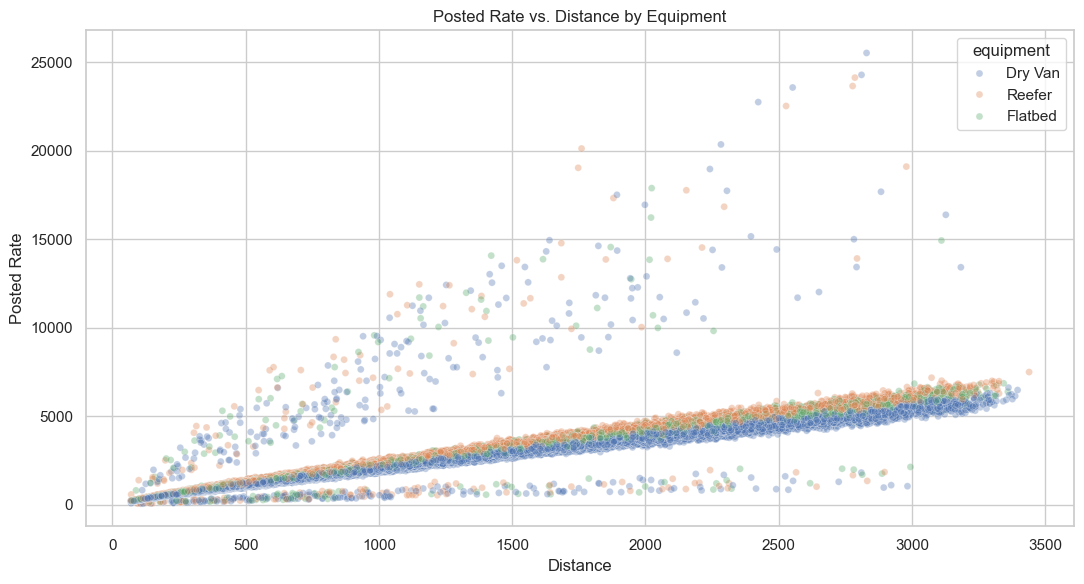

In [15]:
plot_df = df[['distance', 'posted_rate', 'equipment']].dropna().copy()

plt.figure(figsize=(11, 6))
sns.scatterplot(data=plot_df, x='distance', y='posted_rate', hue='equipment', alpha=0.35, s=25)
plt.title('Posted Rate vs. Distance by Equipment')
plt.xlabel('Distance')
plt.ylabel('Posted Rate')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_distance_vs_rate.png', dpi=300, bbox_inches='tight')
plt.show()


## Equipment analysis

Dry Van is the most common equipment type, followed by Reefer and Flatbed, so the classes are not equally represented. Their rate distributions also differ in both center and spread.

Because `posted_rate` contains high-value outliers, the median is particularly useful alongside the mean. Differences between equipment groups support keeping `equipment` as an explanatory feature rather than treating all loads as having the same rate structure.


,count,mean,median,std,share_pct
equipment,,,,,
Dry Van,27202,"2,271.549","1,953.035","1,423.030",56.671
Reefer,12045,"2,553.637","2,196.670","1,589.671",25.094
Flatbed,8753,"2,445.087","2,076.810","1,505.053",18.235


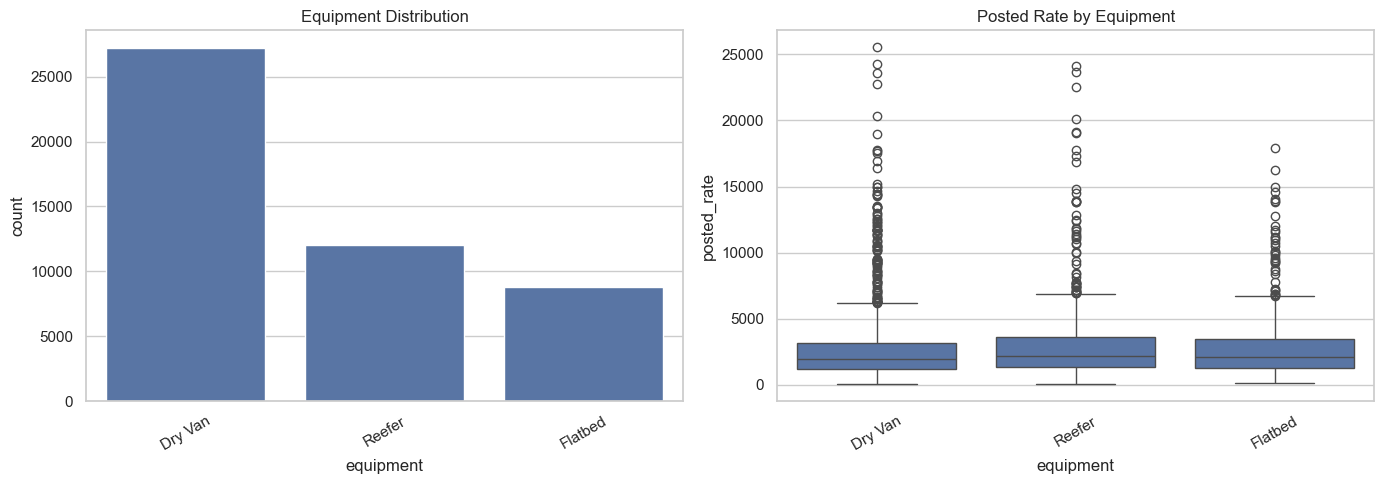

In [16]:
equipment_stats = (
    df.groupby('equipment')['posted_rate']
      .agg(count='size', mean='mean', median='median', std='std')
      .sort_values('count', ascending=False)
)
equipment_stats['share_pct'] = equipment_stats['count'] / len(df) * 100
display(equipment_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='equipment', ax=axes[0])
axes[0].set_title('Equipment Distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='equipment', y='posted_rate', ax=axes[1])
axes[1].set_title('Posted Rate by Equipment')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_equipment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## Temporal patterns

The labeled data spans **January 1 through October 31, 2025**. Average and median freight rates change over this period rather than remaining perfectly stationary.

The difference between daily means and medians is consistent with the right-skewed target distribution, while the month-level changes indicate that time is relevant to the problem. This temporal variation is one of the main reasons a chronological validation design is more realistic than a random split.


,month,mean,median,std,count
0,2025-01,"2,255.967","1,915.200","1,454.275",4918
1,2025-02,"2,273.805","1,994.250","1,317.077",4337
2,2025-03,"2,372.268","2,022.920","1,462.532",5036
3,2025-04,"2,372.162","2,044.240","1,463.102",4819
4,2025-05,"2,421.776","2,065.510","1,486.071",4913
5,2025-06,"2,497.030","2,120.220","1,606.707",4783
6,2025-07,"2,415.162","2,059.145","1,504.943",4912
7,2025-08,"2,338.408","2,015.730","1,474.980",4759
8,2025-09,"2,406.374","2,057.130","1,523.484",4670
9,2025-10,"2,379.051","2,035.900","1,528.714",4853


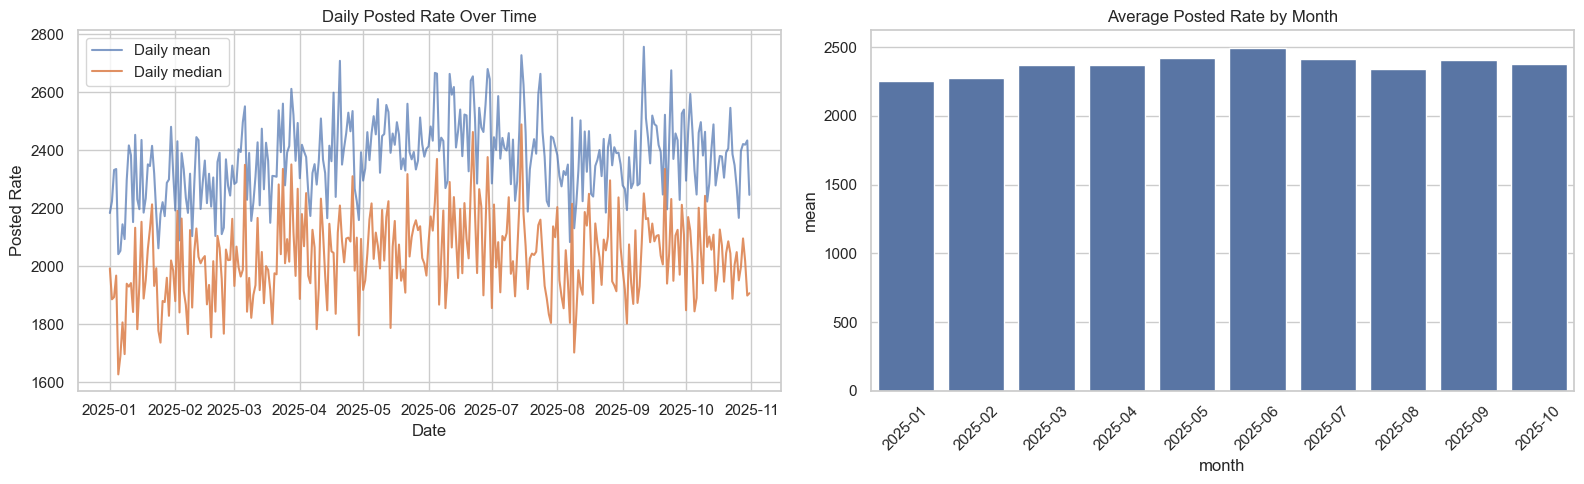

In [17]:
daily = (
    df.groupby('date')['posted_rate']
      .agg(mean='mean', median='median', count='size')
      .reset_index()
)

monthly = (
    df.assign(month=df['date'].dt.to_period('M').astype(str))
      .groupby('month')['posted_rate']
      .agg(mean='mean', median='median', std='std', count='size')
      .reset_index()
)

display(monthly)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(daily['date'], daily['mean'], label='Daily mean', alpha=0.7)
axes[0].plot(daily['date'], daily['median'], label='Daily median', alpha=0.9)
axes[0].set_title('Daily Posted Rate Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Posted Rate')
axes[0].legend()

sns.barplot(data=monthly, x='month', y='mean', ax=axes[1])
axes[1].set_title('Average Posted Rate by Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


##  Negative weight investigation

There are **292 observations with negative weight values** in the original development data. The negative values reach approximately the same magnitude as the positive range, which is more consistent with an erroneous sign than with a separate physical measurement scale.

Using the absolute value preserves the magnitude of the shipment while correcting the impossible sign. This is therefore a reasonable data-quality assumption for the current analysis, while the original rows remain identifiable in the raw dataset.


In [18]:
negative_weight_rows = df[df['weight'] <= 0].copy()
print(f'Non-positive weight rows: {len(negative_weight_rows):,}')
print(f'Negative weight minimum: {negative_weight_rows["weight"].min()}')
print(f'Positive weight maximum: {df["weight"].max()}')

display(
    negative_weight_rows[['weight', 'distance', 'equipment', 'posted_rate']]
    .head(20)
)


Non-positive weight rows: 292
Negative weight minimum: -47500.0
Positive weight maximum: 47500.0


,weight,distance,equipment,posted_rate
68,"-36,559.000","1,334.200",Reefer,"2,831.270"
204,"-26,670.000",496.200,Dry Van,"1,046.920"
206,"-20,003.000",411.300,Reefer,959.150
225,"-23,981.000","1,317.400",Reefer,"2,836.000"
376,"-41,397.000","1,331.100",Dry Van,"2,522.540"
446,"-37,215.000","2,438.300",Reefer,"4,841.570"
495,"-31,214.000",715.900,Dry Van,"1,473.780"
641,"-41,023.000",582.400,Dry Van,"1,264.330"
806,"-28,320.000",676.100,Dry Van,"1,307.760"
1093,"-25,153.000","1,058.500",Dry Van,"1,907.830"


## Validation strategy — chronological split

The development data covers January through October, while the final unlabeled `validation.csv` covers **November and December 2025**. The validation setup should therefore measure how well a model trained on earlier history generalizes to a later period.

The main split uses **January–August for training** and **September–October for validation**. This creates a two-month holdout immediately before the final two-month prediction period and preserves the natural ordering of the data.

A random split would mix earlier and later market conditions across both sets and could produce an overly optimistic estimate for a task whose real objective is future prediction.


In [19]:
VALIDATION_START = pd.Timestamp('2025-09-01')

train = df[df['date'] < VALIDATION_START].copy()
val = df[df['date'] >= VALIDATION_START].copy()

print('TEMPORAL SPLIT')
print('=' * 60)
print(f'Train:      {len(train):,} rows ({len(train)/len(df)*100:.1f}%)')
print(f'Validation: {len(val):,} rows ({len(val)/len(df)*100:.1f}%)')
print(f'Train:      {train["date"].min().date()} -> {train["date"].max().date()}')
print(f'Validation: {val["date"].min().date()} -> {val["date"].max().date()}')

assert train['date'].max() < val['date'].min()
assert set(train['load_id']).isdisjoint(set(val['load_id']))
print('\n✓ No chronological overlap and no load_id overlap.')


TEMPORAL SPLIT
Train:      38,477 rows (80.2%)
Validation: 9,523 rows (19.8%)
Train:      2025-01-01 -> 2025-08-31
Validation: 2025-09-01 -> 2025-10-31

✓ No chronological overlap and no load_id overlap.


##  Preprocessing 

The missing-value statistics used during preprocessing are themselves learned from data. Fitting them only on the January–August training period keeps the September–October validation set independent from the training process.

For `weight`, the sign correction is applied first and the remaining missing values are filled with the training median. `market_index` is also imputed with the training-period median. The exact same fitted values are then reused for validation data.


In [20]:
def fit_preprocessing(train_df):
    """Fit preprocessing statistics using TRAIN ONLY."""
    stats = {
        'weight_median': train_df['weight'].abs().median(),
        'market_index_median': train_df['market_index'].median(),
    }
    return stats


def apply_preprocessing(data, stats):
    """Apply already-fitted preprocessing without refitting on new data."""
    out = data.copy()
    out['weight'] = out['weight'].abs()
    out['weight'] = out['weight'].fillna(stats['weight_median'])
    out['market_index'] = out['market_index'].fillna(stats['market_index_median'])
    return out


preprocessing_stats = fit_preprocessing(train)
train_clean = apply_preprocessing(train, preprocessing_stats)
val_clean = apply_preprocessing(val, preprocessing_stats)

print('Training medians used for preprocessing:')
print(preprocessing_stats)
print('\nRemaining missing values in cleaned train:')
print(train_clean[['weight', 'market_index']].isna().sum())
print('\nRemaining missing values in cleaned validation:')
print(val_clean[['weight', 'market_index']].isna().sum())
print('\nNegative weights after cleaning:')
print((train_clean['weight'] < 0).sum(), (val_clean['weight'] < 0).sum())


Training medians used for preprocessing:
{'weight_median': np.float64(31472.5), 'market_index_median': np.float64(1.12)}

Remaining missing values in cleaned train:
weight          0
market_index    0
dtype: int64

Remaining missing values in cleaned validation:
weight          0
market_index    0
dtype: int64

Negative weights after cleaning:
0 0


## Train vs. validation distributions

Comparing the two time periods helps quantify whether the model will be evaluated under conditions that differ from those seen during training. Some movement between the train and validation statistics is expected because the split is intentionally chronological.

Such differences are informative rather than undesirable: the final prediction period is also later in time, so moderate distribution shift makes the holdout more representative of the actual task. Equipment proportions are checked separately to make sure that any change is not simply caused by a major shift in category composition.


In [21]:
comparison_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

rows = []
for col in comparison_cols:
    rows.append({
        'feature': col,
        'train_mean': train[col].mean(),
        'val_mean': val[col].mean(),
        'train_median': train[col].median(),
        'val_median': val[col].median(),
    })

distribution_comparison = pd.DataFrame(rows)
display(distribution_comparison)

equipment_comparison = pd.concat([
    train['equipment'].value_counts(normalize=True).rename('train_share'),
    val['equipment'].value_counts(normalize=True).rename('val_share')
], axis=1).fillna(0)
equipment_comparison['difference_pp'] = (equipment_comparison['val_share'] - equipment_comparison['train_share']) * 100
display(equipment_comparison)


,feature,train_mean,val_mean,train_median,val_median
0,distance,"1,136.009","1,135.243",954.800,945.800
1,weight,"30,991.678","31,179.120","31,405.000","31,562.000"
2,market_index,1.122,0.926,1.120,0.928
3,quote_signal,2.061,2.069,2.054,2.065
4,posted_rate,"2,369.410","2,392.450","2,026.040","2,044.320"


,train_share,val_share,difference_pp
equipment,,,
Dry Van,0.568,0.563,-0.482
Reefer,0.251,0.251,0.044
Flatbed,0.181,0.186,0.438


## Final validation-period sanity check

The supplied `validation.csv` contains **12,000 unique loads** dated from **November 1 through December 31, 2025**. This confirms that the September–October development holdout closely mirrors the forecasting horizon of the final evaluation.

The chronology is therefore consistent across the whole setup: historical training data first, an unseen development holdout next, and the final November–December prediction period after that.


In [24]:
validation_path = DATA_DIR / 'validation.csv'

if validation_path.exists():
    final_validation = pd.read_csv(validation_path, parse_dates=['date'])
    print(f'Final validation shape: {final_validation.shape}')
    print(f'Final validation period: {final_validation["date"].min().date()} -> {final_validation["date"].max().date()}')
    print(f'Unique load_id: {final_validation["load_id"].nunique():,}')
else:
    print('validation.csv not found locally.')


Final validation shape: (12000, 13)
Final validation period: 2025-11-01 -> 2025-12-31
Unique load_id: 12,000


## Feature availability in the December chart input

The separate December chart input contains `pickup`, `delivery`, `distance`, `equipment`, `weight`, and `date`, but it does not contain coordinates, `market_index`, or `quote_signal`.

This creates an important modeling constraint. A feature may look useful during development but cannot be part of a single final prediction pipeline if its value is unavailable for one of the required prediction outputs. The richer columns can still be analyzed experimentally, but final feature selection has to account for this difference in input schemas.


In [23]:
december_columns = [
    'pickup', 'delivery', 'distance', 'equipment', 'weight', 'date'
]

validation_columns = set(final_validation.columns) if validation_path.exists() else set()
development_columns = set(df.columns)

print('Development-only columns not available in December inputs:')
print(sorted(development_columns - set(december_columns) - {'load_id', 'posted_rate'}))

if validation_columns:
    print('\nValidation columns missing from December inputs:')
    print(sorted(validation_columns - set(december_columns) - {'load_id'}))


Development-only columns not available in December inputs:
['delivery_lat', 'delivery_lon', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']

Validation columns missing from December inputs:
['delivery_lat', 'delivery_lon', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']


## EDA summary

The exploratory analysis shows that `distance` is the strongest individual predictor of freight rate, while `equipment` adds meaningful differences in the rate distribution. The target itself is strongly right-skewed and contains a long upper tail, so model evaluation should pay attention to errors on expensive loads rather than relying only on the visual fit around the center of the distribution.

The main data-quality issues are limited missing values in `weight` and `market_index` and a small group of negative weights that are most plausibly sign errors. These issues can be handled without removing observations and without using information from the validation period.

The data also shows temporal variation, making the **January–August → September–October** split a realistic development setup for the final **November–December** prediction task. Finally, the reduced schema of the December chart inputs means feature availability must remain part of the model-selection decision.


## Modeling
Model performance is evaluated on the previously defined temporal holdout: January–August for training and September–October for validation. This preserves the chronological structure of the data and provides a realistic approximation of predicting future freight rates.

Since the final scoring metric is not exposed by the provided scoring script, several standard regression metrics are tracked during model development. MAE is used as the primary comparison metric because it provides an interpretable estimate of the typical prediction error in dollars, while RMSE and R² provide additional information about large errors and overall explained variance.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = 'posted_rate'

def evaluate_predictions(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

baseline_prediction = np.full(
    len(val_clean),
    train_clean[TARGET].median()
)

baseline_metrics = evaluate_predictions(
    val_clean[TARGET],
    baseline_prediction
)

pd.Series(baseline_metrics).round(3)

MAE    1,148.924
RMSE   1,569.424
R2        -0.058
dtype: float64

The median baseline produces an MAE of approximately $1,149 and an RMSE of $1,569 on the temporal validation set. The relatively large gap between MAE and RMSE indicates that some observations result in substantially larger prediction errors, which is consistent with the long right tail observed in the target distribution.

The negative R² confirms that a constant prediction does not explain the variation in freight rates. This baseline therefore provides a simple reference point against which models using shipment characteristics can be evaluated.

### Distance-based baseline

Distance showed the strongest individual relationship with `posted_rate` during EDA. A simple linear regression using only distance provides a useful second baseline and helps quantify how much of the rate variation can be explained by mileage alone.

In [29]:
from sklearn.linear_model import LinearRegression

X_train_distance = train_clean[['distance']]
X_val_distance = val_clean[['distance']]

y_train = train_clean[TARGET]
y_val = val_clean[TARGET]

distance_model = LinearRegression()

distance_model.fit(X_train_distance, y_train)

distance_predictions = distance_model.predict(X_val_distance)

distance_metrics = evaluate_predictions(
    y_val,
    distance_predictions
)

pd.Series(distance_metrics).round(3)

MAE    196.950
RMSE   654.416
R2       0.816
dtype: float64

In [30]:
print(f'Intercept: ${distance_model.intercept_:,.2f}')
print(f'Rate per mile coefficient: ${distance_model.coef_[0]:,.2f}')

Intercept: $268.90
Rate per mile coefficient: $1.85


The distance-only linear model substantially improves over the constant baseline, reducing MAE from approximately $1,149 to $197 and achieving an R² of 0.816.

This confirms the strong relationship between shipment distance and freight rate observed during EDA. Distance alone explains a large proportion of rate variation, although the considerably higher RMSE ($654) indicates that a smaller number of loads still produce large prediction errors.

The remaining error suggests that distance captures the general pricing structure well, while additional shipment, route, equipment, and temporal characteristics may help explain deviations from this relationship.

### Common-feature model

The next model uses the shipment characteristics that are available in both the final validation dataset and the fixed December prediction dataset.

This feature set provides a consistent modeling pipeline for both required outputs and establishes whether the core shipment information is sufficient to explain the remaining variation beyond distance alone.

Simple calendar features are derived from `date` to allow the model to capture temporal variation observed during EDA.

In [31]:
COMMON_FEATURES = [
    'pickup',
    'delivery',
    'distance',
    'equipment',
    'weight',
    'date'
]

CATEGORICAL_FEATURES = [
    'pickup',
    'delivery',
    'equipment'
]


def create_model_features(df):
    features = df[COMMON_FEATURES].copy()

    features['date'] = pd.to_datetime(features['date'])

    features['month'] = features['date'].dt.month
    features['day_of_week'] = features['date'].dt.dayofweek
    features['day_of_month'] = features['date'].dt.day

    # Continuous representation of time
    reference_date = pd.Timestamp('2025-01-01')
    features['days_since_start'] = (
        features['date'] - reference_date
    ).dt.days

    features = features.drop(columns='date')

    return features


X_train_common = create_model_features(train_clean)
X_val_common = create_model_features(val_clean)

y_train = train_clean[TARGET]
y_val = val_clean[TARGET]

X_train_common.head()

,pickup,delivery,distance,equipment,weight,month,day_of_week,day_of_month,days_since_start
0,Richmond,Baltimore,274.300,Dry Van,"30,658.000",1,2,1,0
1,Richmond,Philadelphia,280.500,Reefer,"17,555.000",1,2,1,0
2,Philadelphia,Green Bay,967.800,Dry Van,"31,721.000",1,2,1,0
3,Hartford,Atlanta,965.400,Dry Van,"32,333.000",1,2,1,0
4,Dallas,Nashville,541.900,Reefer,"35,183.000",1,2,1,0


In [33]:
from catboost import CatBoostRegressor
catboost_common = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

catboost_common.fit(
    X_train_common,
    y_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_val_common, y_val),
    early_stopping_rounds=100
)

catboost_common_predictions = catboost_common.predict(X_val_common)

catboost_common_metrics = evaluate_predictions(
    y_val,
    catboost_common_predictions
)

pd.Series(catboost_common_metrics).round(3)

0:	learn: 1073.6472290	test: 1097.1938062	best: 1097.1938062 (0)	total: 67.4ms	remaining: 1m 7s
100:	learn: 111.5094941	test: 127.9298380	best: 127.9298380 (100)	total: 877ms	remaining: 7.81s
200:	learn: 98.1445250	test: 116.3702667	best: 116.3702667 (200)	total: 1.66s	remaining: 6.58s
300:	learn: 93.4046981	test: 114.6261203	best: 114.5830871 (295)	total: 2.4s	remaining: 5.58s
400:	learn: 90.4774804	test: 113.8128919	best: 113.7792594 (398)	total: 3.13s	remaining: 4.68s
500:	learn: 88.6787656	test: 113.1790670	best: 113.1338346 (498)	total: 3.87s	remaining: 3.85s
600:	learn: 87.1789895	test: 112.9003651	best: 112.9003651 (600)	total: 4.61s	remaining: 3.06s
700:	learn: 85.8217567	test: 112.8779447	best: 112.8243463 (616)	total: 5.36s	remaining: 2.28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 112.8243463
bestIteration = 616

Shrink model to first 617 iterations.


MAE    112.824
RMSE   635.093
R2       0.827
dtype: float64

The common-feature CatBoost model achieves an MAE of approximately $113, improving substantially over the distance-only baseline MAE of $197. This indicates that shipment characteristics beyond distance provide meaningful additional predictive information.

The improvement in RMSE is considerably smaller ($654 to $635), suggesting that while the model improves predictions for typical loads, a relatively small number of observations still produce very large errors. These cases will require further investigation during error analysis.

Early stopping selected iteration 616 as the best-performing point on the temporal validation set, preventing unnecessary additional fitting once validation performance stopped improving.

### Prediction error distribution

Although the common-feature model achieves a relatively low MAE, its RMSE remains much higher. The distribution of residuals is examined to determine whether this difference is caused by a small number of unusually large prediction errors.

In [44]:
error_analysis = val_clean[
    ['load_id', 'pickup', 'delivery', 'distance',
     'equipment', 'weight', 'date', TARGET]
].copy()

error_analysis['predicted_rate'] = catboost_common_predictions

error_analysis['residual'] = (
    error_analysis[TARGET] -
    error_analysis['predicted_rate']
)

error_analysis['absolute_error'] = error_analysis['residual'].abs()

error_analysis['percentage_error'] = (
    error_analysis['absolute_error'] /
    error_analysis[TARGET] * 100
)

error_analysis['absolute_error'].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)


count    9,523.000
mean       112.820
std        625.020
min          0.010
50%         38.400
75%         79.080
90%        143.270
95%        196.310
99%      1,539.550
max     16,270.210
Name: absolute_error, dtype: float64

In [38]:
error_analysis.nlargest(
    20,
    'absolute_error'
)[
    ['load_id', 'pickup', 'delivery', 'distance',
     'equipment', TARGET, 'predicted_rate',
     'absolute_error']
]

,load_id,pickup,delivery,distance,equipment,posted_rate,predicted_rate,absolute_error
40096,TR-040097,Baltimore,Oklahoma City,"1,760.300",Reefer,"20,132.370","3,862.160","16,270.210"
40171,TR-040172,Montgomery,Fresno,"2,283.400",Dry Van,"20,361.890","4,347.348","16,014.542"
43539,TR-043540,Milwaukee,Bakersfield,"1,893.000",Dry Van,"17,514.110","3,581.396","13,932.714"
46213,TR-046214,Columbia,Tucson,"2,023.400",Flatbed,"17,893.170","4,123.370","13,769.800"
47298,TR-047299,Boston,Bakersfield,"2,979.100",Reefer,"19,110.300","5,891.673","13,218.627"
40322,TR-040323,Montgomery,El Paso,"1,639.900",Dry Van,"14,949.250","3,278.435","11,670.815"
46516,TR-046517,Toledo,Albuquerque,"1,684.300",Reefer,"14,784.380","3,615.612","11,168.768"
42881,TR-042882,San Antonio,Detroit,"1,460.500",Dry Van,"13,503.630","2,885.408","10,618.222"
47536,TR-047537,Los Angeles,Richmond,"2,782.400",Dry Van,"15,003.550","4,854.021","10,149.529"
42149,TR-042150,Grand Rapids,Lubbock,"1,415.500",Dry Van,"13,026.220","2,886.235","10,139.985"


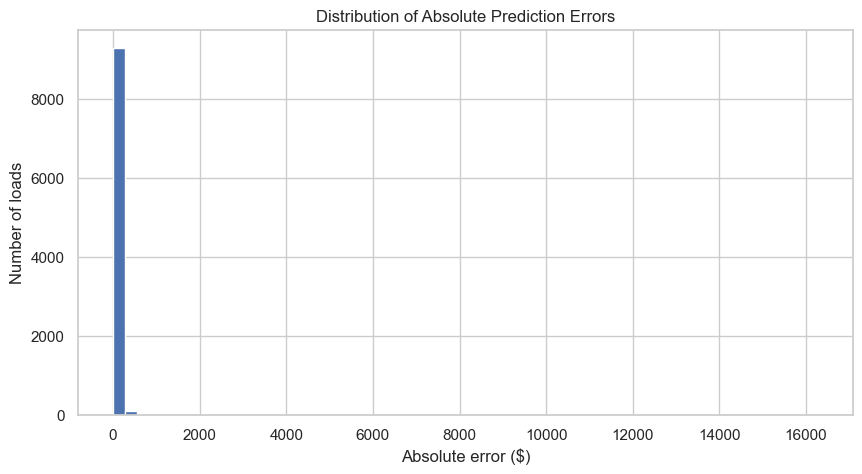

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    error_analysis['absolute_error'],
    bins=60
)

ax.set_title('Distribution of Absolute Prediction Errors')
ax.set_xlabel('Absolute error ($)')
ax.set_ylabel('Number of loads')

plt.show()

The error distribution is strongly right-skewed. The median absolute error is only about $38, and 95% of validation predictions are within approximately $196 of the observed rate. This indicates that the model performs well for the large majority of loads.

However, the top 1% of observations contain substantially larger errors, with the maximum exceeding $16,000. Inspection of the largest residuals shows that these cases are primarily unusually high observed freight rates that the model predicts much closer to the typical rate expected from their shipment characteristics.

These extreme observations explain the large difference between MAE and RMSE and suggest that further improvements may depend on identifying whether additional features contain information capable of explaining these unusually high rates.

### Extended feature model

The common-feature model performs well for most validation observations, while its largest errors are concentrated in a small number of unusually high freight rates.

The development and final validation datasets contain additional numerical information that is not available in the fixed December chart inputs. An extended model is therefore evaluated to determine whether `market_index`, `quote_signal`, and geographic coordinates provide additional information capable of explaining the remaining prediction errors.

This experiment also helps quantify the predictive value of these features before deciding whether they should be included in the final validation model.

In [45]:
EXTENDED_FEATURES = [
    'pickup',
    'delivery',
    'pickup_lat',
    'pickup_lon',
    'delivery_lat',
    'delivery_lon',
    'distance',
    'equipment',
    'weight',
    'market_index',
    'quote_signal',
    'date'
]


def create_extended_features(df):
    features = df[EXTENDED_FEATURES].copy()

    features['date'] = pd.to_datetime(features['date'])

    features['month'] = features['date'].dt.month
    features['day_of_week'] = features['date'].dt.dayofweek
    features['day_of_month'] = features['date'].dt.day

    reference_date = pd.Timestamp('2025-01-01')
    features['days_since_start'] = (
        features['date'] - reference_date
    ).dt.days

    features = features.drop(columns='date')

    return features


X_train_extended = create_extended_features(train_clean)
X_val_extended = create_extended_features(val_clean)

In [46]:
catboost_extended = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

catboost_extended.fit(
    X_train_extended,
    y_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_val_extended, y_val),
    early_stopping_rounds=100
)

catboost_extended_predictions = catboost_extended.predict(
    X_val_extended
)

extended_metrics = evaluate_predictions(
    y_val,
    catboost_extended_predictions
)

pd.Series(extended_metrics).round(3)

0:	learn: 1073.7102745	test: 1099.8705933	best: 1099.8705933 (0)	total: 12ms	remaining: 12s
100:	learn: 105.6046708	test: 128.2308203	best: 128.2308203 (100)	total: 891ms	remaining: 7.93s
200:	learn: 90.0798973	test: 117.1694109	best: 117.0611023 (192)	total: 1.72s	remaining: 6.85s
300:	learn: 85.0005177	test: 116.4552781	best: 116.4552781 (300)	total: 2.56s	remaining: 5.95s
400:	learn: 81.6704326	test: 117.2602762	best: 116.4552781 (300)	total: 3.37s	remaining: 5.03s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 116.4552781
bestIteration = 300

Shrink model to first 301 iterations.


MAE    116.455
RMSE   636.398
R2       0.826
dtype: float64

In [47]:
model_comparison = pd.DataFrame({
    'Median baseline': baseline_metrics,
    'Distance linear regression': distance_metrics,
    'CatBoost common': catboost_common_metrics,
    'CatBoost extended': extended_metrics
}).T

model_comparison.round(3)

,MAE,RMSE,R2
Median baseline,"1,148.924","1,569.424",-0.058
Distance linear regression,196.950,654.416,0.816
CatBoost common,112.824,635.093,0.827
CatBoost extended,116.455,636.398,0.826


The extended feature set does not improve validation performance. Its MAE increases slightly from $112.82 to $116.46, while RMSE and R² remain effectively unchanged.

This suggests that the additional geographic coordinates, `market_index`, and `quote_signal` do not provide enough incremental predictive information beyond the core shipment characteristics under the current temporal validation setup.

The common-feature model is therefore preferable at this stage: it achieves slightly better validation performance, uses a simpler feature set, and relies only on information that is also available for the required fixed December predictions.

### Feature importance

The common-feature CatBoost model substantially outperforms the distance-only baseline, indicating that additional shipment characteristics contribute useful predictive information.

Feature importance is examined to understand which variables the model relies on most heavily and whether the improvement is driven primarily by distance or distributed across route, equipment, weight, and temporal information.

In [48]:
feature_importance = pd.DataFrame({
    'feature': X_train_common.columns,
    'importance': catboost_common.get_feature_importance()
}).sort_values(
    'importance',
    ascending=False
)

feature_importance

,feature,importance
2,distance,92.274
3,equipment,3.155
8,days_since_start,1.027
4,weight,1.026
5,month,0.736
1,delivery,0.680
0,pickup,0.538
6,day_of_week,0.362
7,day_of_month,0.202


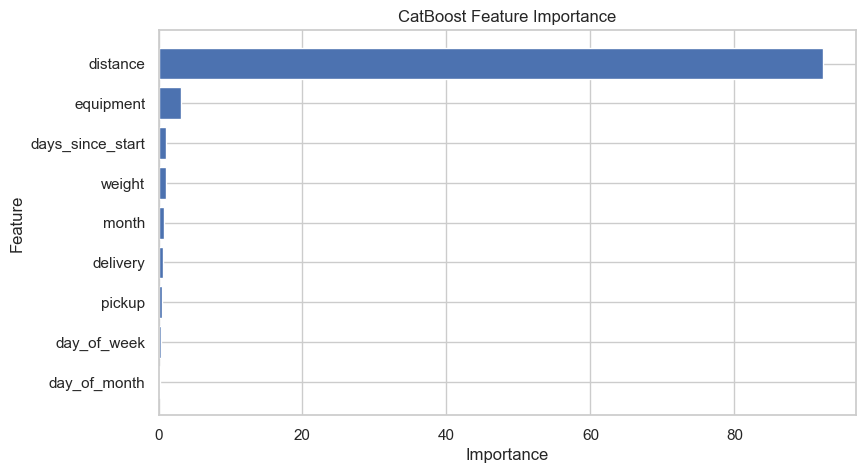

In [49]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance['feature'][::-1],
    feature_importance['importance'][::-1]
)

plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

The feature importance analysis confirms that distance dominates the CatBoost model, accounting for more than 90% of the model's feature importance. This is consistent with both the EDA and the strong performance of the distance-only linear baseline.

Equipment provides the largest secondary contribution, while weight, route information, and temporal features have considerably smaller individual importance. Despite their relatively low importance, these additional features collectively help reduce MAE from approximately $197 for the distance-only model to $113 for CatBoost.

The dominance of distance suggests that the underlying freight pricing structure is largely mileage-driven, while the remaining features primarily help the model adjust the base distance-rate relationship.

### Log-transformed target

The target distribution contains a pronounced right tail, and the previous error analysis showed that a small number of unusually high rates account for the largest prediction errors.

A log-transformed target is evaluated to reduce the influence of extreme rate values during training. Predictions are transformed back to the original dollar scale before evaluation so that the results remain directly comparable with the previous models.

In [50]:
y_train_log = np.log1p(y_train)

catboost_log = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

catboost_log.fit(
    X_train_common,
    y_train_log,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_val_common, np.log1p(y_val)),
    early_stopping_rounds=100
)

log_predictions = np.expm1(
    catboost_log.predict(X_val_common)
)

log_metrics = evaluate_predictions(
    y_val,
    log_predictions
)

pd.Series(log_metrics).round(3)

0:	learn: 0.5114153	test: 0.5174972	best: 0.5174972 (0)	total: 9.46ms	remaining: 9.46s
100:	learn: 0.0481491	test: 0.0529978	best: 0.0529978 (100)	total: 819ms	remaining: 7.29s
200:	learn: 0.0399581	test: 0.0461607	best: 0.0461607 (200)	total: 1.59s	remaining: 6.34s
300:	learn: 0.0371311	test: 0.0445464	best: 0.0445464 (300)	total: 2.38s	remaining: 5.53s
400:	learn: 0.0355494	test: 0.0438406	best: 0.0438406 (400)	total: 3.11s	remaining: 4.65s
500:	learn: 0.0345242	test: 0.0437413	best: 0.0434536 (499)	total: 3.9s	remaining: 3.88s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.04345360201
bestIteration = 499

Shrink model to first 500 iterations.


MAE    112.151
RMSE   634.938
R2       0.827
dtype: float64

In [51]:
log_absolute_errors = np.abs(
    y_val.to_numpy() - log_predictions
)

pd.DataFrame({
    'Regular CatBoost': error_analysis['absolute_error'].describe(
        percentiles=[.50, .75, .90, .95, .99]
    ),
    'Log-target CatBoost': pd.Series(log_absolute_errors).describe(
        percentiles=[.50, .75, .90, .95, .99]
    )
}).round(2)

,Regular CatBoost,Log-target CatBoost
count,"9,523.000","9,523.000"
mean,112.820,112.150
std,625.020,624.990
min,0.010,0.000
50%,38.400,38.650
75%,79.080,78.420
90%,143.270,138.210
95%,196.310,196.120
99%,"1,539.550","1,527.590"
max,"16,270.210","16,316.170"


The log-transformed target produces only a marginal improvement over the regular CatBoost model. MAE decreases from $112.82 to $112.15, while RMSE and R² remain effectively unchanged.

The error distribution is also very similar. The log-target model slightly improves errors around the 90th and 99th percentiles, but does not reduce the most extreme errors.

This suggests that target skewness itself is not the main reason for the remaining large prediction errors. The regular and log-target models capture essentially the same underlying structure, so the small improvement from the transformation is not sufficient on its own to justify a clear preference.

### Extra Trees model

To compare CatBoost with a different tree-based modeling approach, an Extra Trees regressor is evaluated on the same temporal validation split.

Unlike gradient boosting, Extra Trees combines many randomized decision trees independently. Categorical variables are one-hot encoded so that the model can use the same common shipment information as the previous CatBoost experiments.

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline

categorical_features = [
    'pickup',
    'delivery',
    'equipment'
]

numeric_features = [
    'distance',
    'weight',
    'month',
    'day_of_week',
    'day_of_month',
    'days_since_start'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

extra_trees = ExtraTreesRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

extra_trees_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', extra_trees)
])

extra_trees_pipeline.fit(
    X_train_common,
    y_train
)

extra_trees_predictions = extra_trees_pipeline.predict(
    X_val_common
)

extra_trees_metrics = evaluate_predictions(
    y_val,
    extra_trees_predictions
)

pd.Series(extra_trees_metrics).round(3)

MAE    165.504
RMSE   691.846
R2       0.794
dtype: float64

In [53]:
model_comparison = pd.DataFrame({
    'Median baseline': baseline_metrics,
    'Distance linear regression': distance_metrics,
    'CatBoost common': catboost_common_metrics,
    'CatBoost log-target': log_metrics,
    'CatBoost extended': extended_metrics,
    'Extra Trees': extra_trees_metrics
}).T

model_comparison.round(3)

,MAE,RMSE,R2
Median baseline,"1,148.924","1,569.424",-0.058
Distance linear regression,196.950,654.416,0.816
CatBoost common,112.824,635.093,0.827
CatBoost log-target,112.151,634.938,0.827
CatBoost extended,116.455,636.398,0.826
Extra Trees,165.504,691.846,0.794


The Extra Trees model performs substantially better than the constant baseline but does not match the performance of CatBoost. Its MAE of approximately $166 is considerably higher than the $113 achieved by the common-feature CatBoost model.

The result suggests that the randomized tree ensemble captures the general freight-rate structure but is less effective at modeling the smaller adjustments around the strong distance-driven relationship. CatBoost remains the strongest model evaluated so far.

### XGBoost model

XGBoost is evaluated as an alternative gradient-boosting approach to determine whether the strong performance observed with CatBoost is specific to that implementation or more generally associated with boosted decision trees.

The same common feature set and temporal validation split are retained to ensure that performance differences reflect the modeling approach rather than differences in available information.

In [56]:
from xgboost import XGBRegressor

xgboost_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgboost_model)
])

xgboost_pipeline.fit(
    X_train_common,
    y_train
)

xgboost_predictions = xgboost_pipeline.predict(
    X_val_common
)

xgboost_metrics = evaluate_predictions(
    y_val,
    xgboost_predictions
)

pd.Series(xgboost_metrics).round(3)

MAE    109.118
RMSE   634.018
R2       0.827
dtype: float64

In [59]:
model_comparison = pd.DataFrame({
    'Median baseline': baseline_metrics,
    'Distance linear regression': distance_metrics,
    'Extra Trees': extra_trees_metrics,
    'CatBoost common': catboost_common_metrics,
    'CatBoost extended': extended_metrics,
    'CatBoost log-target': log_metrics,
    'XGBoost': xgboost_metrics
}).T

model_comparison.round(3)

,MAE,RMSE,R2
Median baseline,"1,148.924","1,569.424",-0.058
Distance linear regression,196.950,654.416,0.816
Extra Trees,165.504,691.846,0.794
CatBoost common,112.824,635.093,0.827
CatBoost extended,116.455,636.398,0.826
CatBoost log-target,112.151,634.938,0.827
XGBoost,109.118,634.018,0.827


The XGBoost model achieves the lowest MAE among the models evaluated so far, reducing validation MAE to approximately $109 compared with $113 for the common-feature CatBoost model.

The improvement in RMSE is much smaller, while R² remains approximately unchanged. This suggests that XGBoost provides somewhat more accurate predictions for typical loads but, like CatBoost, does not eliminate the large errors associated with the small group of extreme freight rates.

Overall, gradient-boosting models substantially outperform both the linear baseline and the Extra Trees ensemble. XGBoost currently provides the strongest validation performance, although its advantage over CatBoost is relatively modest.

In [60]:
xgb_error_analysis = val_clean[
    ['load_id', 'pickup', 'delivery', 'distance',
     'equipment', 'weight', 'date', TARGET]
].copy()

xgb_error_analysis['predicted_rate'] = xgboost_predictions

xgb_error_analysis['absolute_error'] = np.abs(
    xgb_error_analysis[TARGET] -
    xgb_error_analysis['predicted_rate']
)

comparison_errors = pd.DataFrame({
    'CatBoost': error_analysis['absolute_error'].describe(
        percentiles=[.50, .75, .90, .95, .99]
    ),
    'XGBoost': xgb_error_analysis['absolute_error'].describe(
        percentiles=[.50, .75, .90, .95, .99]
    )
})

comparison_errors.round(2)

,CatBoost,XGBoost
count,"9,523.000","9,523.000"
mean,112.820,109.120
std,625.020,624.590
min,0.010,0.000
50%,38.400,35.770
75%,79.080,72.850
90%,143.270,134.890
95%,196.310,190.160
99%,"1,539.550","1,511.200"
max,"16,270.210","16,319.330"


In [61]:
xgb_error_analysis.nlargest(
    20,
    'absolute_error'
)[
    ['load_id', 'pickup', 'delivery', 'distance',
     'equipment', TARGET, 'predicted_rate',
     'absolute_error']
]

,load_id,pickup,delivery,distance,equipment,posted_rate,predicted_rate,absolute_error
40096,TR-040097,Baltimore,Oklahoma City,"1,760.300",Reefer,"20,132.370","3,813.040","16,319.330"
40171,TR-040172,Montgomery,Fresno,"2,283.400",Dry Van,"20,361.890","4,446.089","15,915.801"
43539,TR-043540,Milwaukee,Bakersfield,"1,893.000",Dry Van,"17,514.110","3,607.895","13,906.215"
46213,TR-046214,Columbia,Tucson,"2,023.400",Flatbed,"17,893.170","4,078.104","13,815.066"
47298,TR-047299,Boston,Bakersfield,"2,979.100",Reefer,"19,110.300","5,894.914","13,215.386"
40322,TR-040323,Montgomery,El Paso,"1,639.900",Dry Van,"14,949.250","3,286.647","11,662.603"
46516,TR-046517,Toledo,Albuquerque,"1,684.300",Reefer,"14,784.380","3,588.067","11,196.313"
42881,TR-042882,San Antonio,Detroit,"1,460.500",Dry Van,"13,503.630","2,899.291","10,604.339"
42149,TR-042150,Grand Rapids,Lubbock,"1,415.500",Dry Van,"13,026.220","2,846.864","10,179.356"
47536,TR-047537,Los Angeles,Richmond,"2,782.400",Dry Van,"15,003.550","4,828.979","10,174.571"


The comparison of prediction errors confirms that XGBoost's improvement is primarily driven by better performance on typical loads. The median absolute error decreases from approximately $38 to $36, with consistent improvements across the 75th, 90th, 95th, and 99th percentiles.

However, the largest errors remain almost unchanged, and the same observations dominate the extreme-error cases for both CatBoost and XGBoost. These loads have observed rates far above the values predicted from their shipment characteristics.

This suggests that the remaining extreme errors are not specific to the modeling algorithm. Instead, these observations may reflect unusual pricing behavior or information that is not captured by the available common features.

In [62]:
def create_engineered_features(df):
    features = create_model_features(df)

    features['route'] = (
        features['pickup'].astype(str) +
        ' -> ' +
        features['delivery'].astype(str)
    )

    features['distance_band'] = pd.cut(
        features['distance'],
        bins=[0, 500, 1000, 1500, 2000, np.inf],
        labels=[
            'short',
            'medium',
            'long',
            'very_long',
            'extreme'
        ]
    ).astype(str)

    features['equipment_distance_band'] = (
        features['equipment'].astype(str) +
        '_' +
        features['distance_band']
    )

    features['weight_per_distance'] = (
        features['weight'] /
        features['distance'].clip(lower=1)
    )

    return features


X_train_engineered = create_engineered_features(train_clean)
X_val_engineered = create_engineered_features(val_clean)

X_train_engineered.head()

,pickup,delivery,distance,equipment,weight,month,day_of_week,day_of_month,days_since_start,route,distance_band,equipment_distance_band,weight_per_distance
0,Richmond,Baltimore,274.300,Dry Van,"30,658.000",1,2,1,0,Richmond -> Baltimore,short,Dry Van_short,111.768
1,Richmond,Philadelphia,280.500,Reefer,"17,555.000",1,2,1,0,Richmond -> Philadelphia,short,Reefer_short,62.585
2,Philadelphia,Green Bay,967.800,Dry Van,"31,721.000",1,2,1,0,Philadelphia -> Green Bay,medium,Dry Van_medium,32.776
3,Hartford,Atlanta,965.400,Dry Van,"32,333.000",1,2,1,0,Hartford -> Atlanta,medium,Dry Van_medium,33.492
4,Dallas,Nashville,541.900,Reefer,"35,183.000",1,2,1,0,Dallas -> Nashville,medium,Reefer_medium,64.925


In [63]:
ENGINEERED_CATEGORICAL_FEATURES = [
    'pickup',
    'delivery',
    'equipment',
    'route',
    'distance_band',
    'equipment_distance_band'
]

ENGINEERED_NUMERIC_FEATURES = [
    'distance',
    'weight',
    'month',
    'day_of_week',
    'day_of_month',
    'days_since_start',
    'weight_per_distance'
]

In [64]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            ENGINEERED_CATEGORICAL_FEATURES
        ),
        (
            'numeric',
            'passthrough',
            ENGINEERED_NUMERIC_FEATURES
        )
    ]
)

xgboost_engineered = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

xgboost_engineered_pipeline = Pipeline([
    ('preprocessor', engineered_preprocessor),
    ('model', xgboost_engineered)
])

xgboost_engineered_pipeline.fit(
    X_train_engineered,
    y_train
)

xgboost_engineered_predictions = (
    xgboost_engineered_pipeline.predict(
        X_val_engineered
    )
)

xgboost_engineered_metrics = evaluate_predictions(
    y_val,
    xgboost_engineered_predictions
)

pd.Series(xgboost_engineered_metrics).round(3)

MAE    112.883
RMSE   635.073
R2       0.827
dtype: float64

In [65]:
pd.DataFrame({
    'XGBoost original': xgboost_metrics,
    'XGBoost engineered': xgboost_engineered_metrics
}).T.round(3)

,MAE,RMSE,R2
XGBoost original,109.118,634.018,0.827
XGBoost engineered,112.883,635.073,0.827


In [66]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_mape = mean_absolute_percentage_error(
    y_val,
    xgboost_predictions
) * 100

print(f'MAPE: {xgb_mape:.2f}%')

MAPE: 4.79%


The model's mean absolute percentage error on the temporal holdout is 4.79%

The engineered feature set does not improve XGBoost performance. Validation MAE increases from approximately $109 to $113, while RMSE and R² remain effectively unchanged.

Given the strong distance-driven structure already captured by the original features, the additional route, distance-band, and interaction features do not provide sufficient incremental predictive value. The original XGBoost feature set is therefore retained.

Overall, the remaining model error is concentrated primarily in a small number of extreme-rate observations rather than in systematic errors across typical loads. Further feature expansion was therefore not pursued, particularly given the scope and time constraints of the assessment.

## Final Model Selection

XGBoost was selected as the final model because it achieved the best performance on the temporal validation set, with an MAE of $109.12, a MAPE of 4.79%, and an R² of 0.827.

The comparison across several model families showed that gradient-boosting approaches performed best for this dataset. Additional feature engineering did not improve validation performance, so the simpler original feature set was retained.

Error analysis showed that the model performs accurately for the majority of loads, while most of the remaining RMSE is driven by a small number of unusually high freight rates. Similar extreme errors were observed across different models, suggesting that these cases are difficult to explain using the available shipment characteristics.

Based on these results, the original-feature XGBoost model was selected for the final predictions.

## Final Model Training

After model selection was completed, the selected XGBoost pipeline was retrained using the complete January–October development dataset.

The temporal holdout was used only for model evaluation and selection. Once the modeling decisions were finalized, all available labeled observations were used to maximize the amount of training information available for the final November–December predictions.

In [67]:
# Fit preprocessing statistics on all labeled development data
final_preprocessing_stats = fit_preprocessing(df)

full_clean = apply_preprocessing(
    df,
    final_preprocessing_stats
)

X_full = create_model_features(full_clean)
y_full = full_clean[TARGET]

In [71]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

final_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', final_model)
])

final_pipeline.fit(
    X_full,
    y_full
)
final_pipeline.fit(X_full, y_full)

print("Final model trained on full development dataset.")

Final model trained on full development dataset.
